# Label-Agnostic SATURN: Full Experiment Walkthrough

This notebook presents the complete benchmark cell by cell: data inspection, shared SATURN pretraining, the labeled baseline, construction and auditing of the label-free training artifact, InfoNCE, MMD, partial OT, post-hoc evaluation, and the final figures.

The default presentation mode reuses the completed canonical run so the outputs are identical to `label_agnostic_benchmark.ipynb`. Set `REBUILD_FROM_SCRATCH = True` to execute every training stage into a separate directory.

## Experiment design

All four trials begin from the same pretrained SATURN checkpoint.

- **Baseline:** SATURN's original label-aware triplet fine-tuning.
- **InfoNCE:** reciprocal cross-species neighbours inferred from pretrained embeddings and macrogenes.
- **MMD:** pairwise multi-species distribution matching.
- **OT:** entropy-regularized partial optimal transport.

The three label-free trainers can access only embeddings, macrogenes, species identity, and observation IDs. Cell labels are introduced only after training by the shared evaluator.

In [1]:
from pathlib import Path
import json
import os
import shlex
import subprocess
import sys
import time

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch
from IPython.display import Markdown, display

repo_root = next((
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'scripts' / 'run_label_agnostic_benchmark.sh').exists()
), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate the macrogenes repository.')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Presentation mode: reuse the completed run and reproduce its exact outputs.
REBUILD_FROM_SCRATCH = False

canonical_output_dir = repo_root / 'out' / 'label_agnostic_benchmark_clean'
fresh_output_dir = repo_root / 'out' / 'label_agnostic_benchmark_walkthrough'
output_dir = fresh_output_dir if REBUILD_FROM_SCRATCH else canonical_output_dir

SEED = 0
DEVICE = 'cuda'
DEVICE_NUM = 0
EPOCHS = 20
BATCH_SIZE = 512
TRIALS = ['baseline', 'infonce', 'mmd', 'ot']

if REBUILD_FROM_SCRATCH and output_dir == canonical_output_dir:
    raise RuntimeError('Fresh runs must not overwrite the canonical presentation outputs.')
if REBUILD_FROM_SCRATCH and not torch.cuda.is_available():
    raise RuntimeError('A system GPU is required for a fresh run.')

shared_dir = output_dir / 'shared'
baseline_dir = output_dir / 'baseline'
pretrain_model = shared_dir / 'pretrain_model.pt'
centroids = shared_dir / f'centroids_seed{SEED}.pkl'
baseline_model = baseline_dir / 'final_model.pt'
pretrain_adata = baseline_dir / 'saturn_results' / 'adata_pretrain.h5ad'
baseline_adata = baseline_dir / 'saturn_results' / 'final_adata.h5ad'
label_free_artifact = shared_dir / 'label_free_artifact.npz'
evaluation_triplets = shared_dir / 'evaluation_triplets.npz'
artifact_metadata = shared_dir / 'artifact_metadata.json'

shared_dir.mkdir(parents=True, exist_ok=True)
baseline_dir.mkdir(parents=True, exist_ok=True)

base_env = os.environ.copy()
base_env.update({
    'PYTHONHASHSEED': str(SEED),
    'NUMBA_NUM_THREADS': '1',
    'NUMBA_CACHE_DIR': '/tmp/macrogenes-numba-cache',
    'MPLCONFIGDIR': '/tmp/macrogenes-matplotlib',
})

def run_stage(name, command, required_outputs, env=None):
    required_outputs = [Path(path) for path in required_outputs]
    if not REBUILD_FROM_SCRATCH and all(path.exists() for path in required_outputs):
        print(f'✓ {name}: reusing completed outputs')
        for path in required_outputs:
            print(f'  {path.relative_to(repo_root)}')
        return
    print(f'▶ {name}')
    print('  $', shlex.join([str(part) for part in command]))
    started = time.time()
    subprocess.run(
        [str(part) for part in command],
        cwd=repo_root,
        env=env or base_env,
        check=True,
    )
    missing = [path for path in required_outputs if not path.exists()]
    if missing:
        raise FileNotFoundError(f'{name} did not create: {missing}')
    print(f'✓ {name}: completed in {(time.time() - started) / 60:.1f} minutes')

print(f'Repository: {repo_root}')
print(f'Python environment: {sys.prefix}')
print(f'Output directory: {output_dir}')
print(f'Mode: {"fresh GPU run" if REBUILD_FROM_SCRATCH else "canonical presentation outputs"}')

/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Repository: /home/darcy/projects/SATURN-unsupervised
Python environment: /home/darcy/miniconda3/envs/saturn
Output directory: /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean
Mode: canonical presentation outputs


> **Presentation tip:** leave `REBUILD_FROM_SCRATCH = False` for the walkthrough. Every stage remains visible and auditable, but expensive cells reuse the completed artifacts. A fresh RTX 4060 run takes roughly 15–20 minutes, with OT being the slowest stage.

## 1. Inspect the benchmark data

The tiny benchmark contains four species and 11,074 cells. Labels are read here for description and later evaluation, but the label-free fine-tuning artifact deliberately excludes them.

In [2]:
input_table = pd.read_csv(repo_root / 'data' / 'saturn_run_tiny.csv')
display(input_table)

dataset_rows = []
for row in input_table.itertuples(index=False):
    atlas = ad.read_h5ad(repo_root / row.path, backed='r')
    label_column = row.in_label_col
    dataset_rows.append({
        'species': row.species,
        'cells': atlas.n_obs,
        'genes': atlas.n_vars,
        'label_column': label_column,
        'unique_labels': int(atlas.obs[label_column].nunique()),
    })
    atlas.file.close()

dataset_summary = pd.DataFrame(dataset_rows)
display(dataset_summary)
print(f'Total cells: {dataset_summary.cells.sum():,}')

,species,path,embedding_path,in_label_col
0,a_queenslandica,data/cell_atlases/a_queenslandica.h5ad,data/gene_embeddings/esmc600_embeddings_summar...,cellType
1,c_elegans,data/cell_atlases/c_elegans.h5ad,data/gene_embeddings/esmc600_embeddings_summar...,cellType
2,c_gigas,data/cell_atlases/c_gigas.h5ad,data/gene_embeddings/esmc600_embeddings_summar...,cellType
3,c_hemisphaerica,data/cell_atlases/c_hemisphaerica.h5ad,data/gene_embeddings/esmc600_embeddings_summar...,cellType


,species,cells,genes,label_column,unique_labels
0,a_queenslandica,804,44719,cellType,7
1,c_elegans,5275,11950,cellType,28
2,c_gigas,2207,15879,cellType,12
3,c_hemisphaerica,2788,17674,cellType,18


Total cells: 11,074


## 2. Shared pretraining and labeled SATURN baseline

This stage performs SATURN pretraining once, saves the shared checkpoint, and then runs the original label-aware metric-learning baseline for 20 epochs.

In [5]:
baseline_env = base_env.copy()
baseline_env.update({
    'SEED': str(SEED),
    'DEVICE': DEVICE,
    'DEVICE_NUM': str(DEVICE_NUM),
    'WORK_DIR': str(baseline_dir) + '/',
    'CENTROIDS_INIT_PATH': str(centroids),
    'PRETRAIN_MODEL_PATH': str(pretrain_model),
    'METRIC_MODEL_PATH': str(baseline_model),
    'PRETRAIN': 'true',
    'METRIC_EPOCHS': str(EPOCHS),
    'METRIC_BATCH_SIZE': str(BATCH_SIZE),
    'POLLING_FREQ': '5',
})

run_stage(
    'shared pretraining + labeled baseline',
    ['bash', repo_root / 'scripts' / 'run_saturn_tiny_benchmark.sh'],
    [pretrain_model, pretrain_adata, baseline_model, baseline_adata],
    env=baseline_env,
)

▶ shared pretraining + labeled baseline
  $ bash /home/darcy/projects/SATURN-unsupervised/scripts/run_saturn_tiny_benchmark.sh


/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Using Device 0
Set seed to 0
After loading the anndata a_queenslandica View of AnnData object with n_obs × n_vars = 804 × 44719
    obs: 'organ', 'cellType', 'species', 'species_type_label', 'truth_labels', 'ref_labels'
After loading the anndata c_elegans View of AnnData object with n_obs × n_vars = 5275 × 11950
    obs: 'organ', 'cellType', 'species', 'species_type_label', 'truth_labels', 'ref_labels'
After loading the anndata c_gigas View of AnnData object with n_obs × n_vars = 2207 × 15879
    obs: 'organ', 'cellType', 'species', 'species_type_label', 'truth_labels', 'ref_labels'
    obsm: 'X_umap'
After loading the anndata c_hemisphaerica View of AnnData object with n_obs × n_vars = 2788 × 17674
    obs: 'organ', 'cellType', 'species', 'species_type_label', 'truth_labels', 'ref_labels'
    obsm: 'X_nca', 'X_pca', 'X_tsne', 'X_umap'
a_queenslandica
c_elegans
c_gigas
c_hemisphaerica
Making Centroids using KMeans (sklearn, not on GPU) and scoring genes against them
Saved centroids and

Epoch 20: L1 Loss 0.0 Rank Loss 4.413863658905029, Avg Loss a_queenslandica: 1108, Avg Loss c_elegans: 784, Avg Loss c_gigas: 993, Avg Loss c_hemisphaerica: 906: 100%|██████████| 20/20 [00:28<00:00,  1.42s/it]  
  0%|          | 0/11 [00:00<?, ?it/s]

Saved Pretrain Model to /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/pretrain_model.pt
Loaded Pretrain Model
Saving Pretrain AnnData


...

Epoch 16 Iteration 0: Loss = 0.07962371408939362, Number of mined triplets = 268
Epoch 17 Iteration 0: Loss = 0.07925455272197723, Number of mined triplets = 342
Epoch 18 Iteration 0: Loss = 0.09091360867023468, Number of mined triplets = 359
Epoch 19 Iteration 0: Loss = 0.08098024874925613, Number of mined triplets = 321
Epoch 20 Iteration 0: Loss = 0.0827055498957634, Number of mined triplets = 326


100%|██████████| 11/11 [00:01<00:00,  9.84it/s]


Saving Metric Model to /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/final_model.pt
Saving Final AnnData


100%|██████████| 11/11 [00:02<00:00,  5.13it/s]


Final AnnData Path: /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/final_adata.h5ad
Final Triplets csv Path: /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/triplets.csv
Final Epoch scores csv Path: /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/epoch_scores.csv
Final Metric history csv Path: /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/metric_history.csv
Final celltype_id Path: /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/celltype_id.pkl
✓ shared pretraining + labeled baseline: completed in 13.3 minutes


In [6]:
pretrained = ad.read_h5ad(pretrain_adata, backed='r')
baseline = ad.read_h5ad(baseline_adata, backed='r')
display(pd.DataFrame([
    {'stage': 'pretrained', 'cells': pretrained.n_obs, 'embedding_dim': pretrained.n_vars, 'macrogenes': pretrained.obsm['macrogenes'].shape[1]},
    {'stage': 'labeled baseline', 'cells': baseline.n_obs, 'embedding_dim': baseline.n_vars, 'macrogenes': baseline.obsm['macrogenes'].shape[1]},
]))
pretrained.file.close()
baseline.file.close()

,stage,cells,embedding_dim,macrogenes
0,pretrained,11074,256,200
1,labeled baseline,11074,256,200


### Pretrained representation before fine-tuning

This is the visual starting point for all four trials. Species are initially almost completely separated, while much of the within-species cell-state structure is already present.

/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 256 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


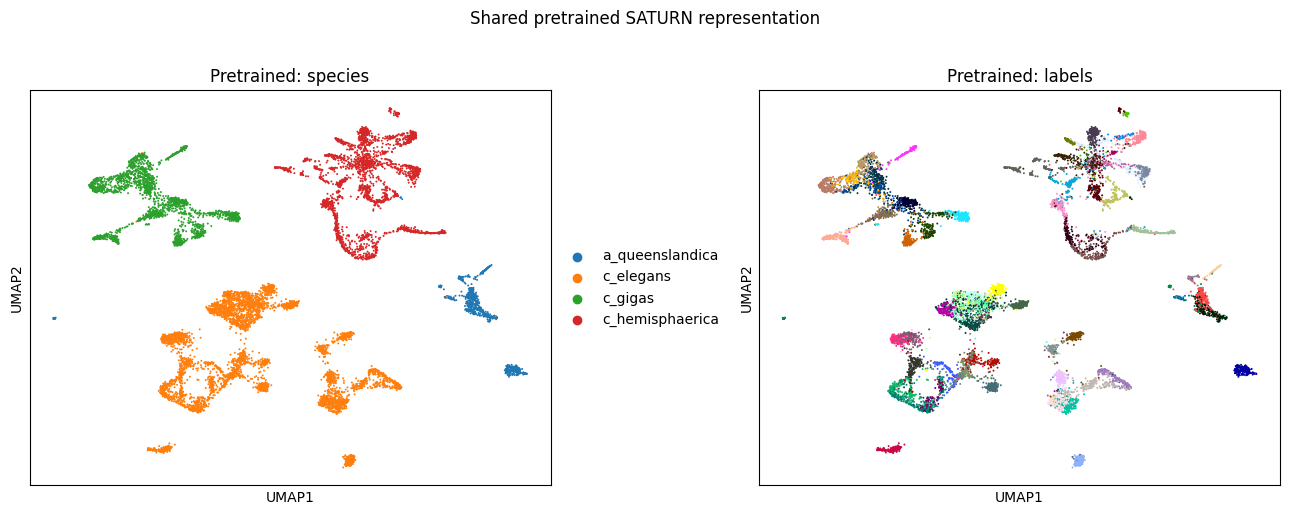

In [7]:
pretrained = ad.read_h5ad(pretrain_adata)
if 'X_umap' not in pretrained.obsm:
    sc.pp.neighbors(pretrained, n_neighbors=15, metric='cosine', random_state=SEED)
    sc.tl.umap(pretrained, min_dist=0.3, random_state=SEED)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(pretrained, color='species', ax=axes[0], show=False, title='Pretrained: species', size=8)
sc.pl.umap(pretrained, color='labels2', ax=axes[1], show=False, title='Pretrained: labels', size=8, legend_loc=None)
fig.suptitle('Shared pretrained SATURN representation', y=1.02)
fig.tight_layout()
plt.show()

In [8]:
from label_agnostic.metrics import embedding_benchmark_metrics

pretrained_metrics = embedding_benchmark_metrics(
    np.asarray(pretrained.X),
    pretrained.obs['species'].astype(str).to_numpy(),
    pretrained.obs['labels2'].astype(str).to_numpy(),
    k=15,
)
display(pd.Series(pretrained_metrics, name='pretrained'))

species_mixing_fraction                        0.000951
label_same_neighbor_fraction                   0.752598
species_macro_mixing_fraction                  0.002206
species_macro_label_same_neighbor_fraction     0.781797
within_species_label_same_neighbor_fraction    0.752941
normalized_species_ilisi                       0.000518
Name: pretrained, dtype: float64

## 3. Build and audit the label-free training artifact

The exporter creates two separate files:

1. A strict training artifact with no label arrays.
2. A frozen label-aware triplet manifest used only by the evaluator after all training is complete.

In [9]:
run_stage(
    'label-free artifact + frozen evaluation triplets',
    [
        sys.executable,
        repo_root / 'scripts' / 'prepare_label_agnostic_artifacts.py',
        '--pretrain-adata', pretrain_adata,
        '--artifact', label_free_artifact,
        '--triplets', evaluation_triplets,
        '--metadata', artifact_metadata,
        '--seed', str(SEED),
        '--batch-size', str(BATCH_SIZE),
    ],
    [label_free_artifact, evaluation_triplets, artifact_metadata],
)

▶ label-free artifact + frozen evaluation triplets
  $ /home/darcy/miniconda3/envs/saturn/bin/python /home/darcy/projects/SATURN-unsupervised/scripts/prepare_label_agnostic_artifacts.py --pretrain-adata /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/adata_pretrain.h5ad --artifact /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/label_free_artifact.npz --triplets /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/evaluation_triplets.npz --metadata /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/artifact_metadata.json --seed 0 --batch-size 512
{
  "batch_size": 512,
  "cell_count": 11074,
  "embedding_dimension": 256,
  "evaluation_labels_used_only_here": true,
  "evaluation_triplet_count": 55341,
  "label_free_artifact_keys": [
    "embeddings",
    "macrogenes",
    "species",
    "obs_ids"
  ],
  "macrogene_dimension": 200,
  "schema

In [10]:
training_artifact = np.load(label_free_artifact, allow_pickle=False)
allowed_keys = {'embeddings', 'macrogenes', 'species', 'obs_ids'}
actual_keys = set(training_artifact.files)
assert actual_keys == allowed_keys
assert not any('label' in key.lower() for key in actual_keys)

artifact_audit = pd.DataFrame([
    {'array': key, 'shape': training_artifact[key].shape, 'dtype': str(training_artifact[key].dtype)}
    for key in training_artifact.files
])
display(artifact_audit)
display(json.loads(artifact_metadata.read_text()))
print('✓ No cell-label field is available to label-free fine-tuning.')

,array,shape,dtype
0,embeddings,"(11074, 256)",float32
1,macrogenes,"(11074, 200)",float32
2,species,"(11074,)",<U15
3,obs_ids,"(11074,)",<U40


{'batch_size': 512,
 'cell_count': 11074,
 'embedding_dimension': 256,
 'evaluation_labels_used_only_here': True,
 'evaluation_triplet_count': 55341,
 'label_free_artifact_keys': ['embeddings',
  'macrogenes',
  'species',
  'obs_ids'],
 'macrogene_dimension': 200,
 'schema_version': 1,
 'seed': 0,
 'species': ['a_queenslandica', 'c_elegans', 'c_gigas', 'c_hemisphaerica']}

✓ No cell-label field is available to label-free fine-tuning.


## 4. Run the three label-free objectives

Each trial loads the same four-field artifact and the same pretrained checkpoint. Checkpoint selection uses species mixing subject to a frozen-neighbour recall constraint; labels are never used for optimization or selection.

In [11]:
def run_label_free_trial(objective):
    trial_dir = output_dir / objective
    command = [
        sys.executable,
        repo_root / 'scripts' / 'train_label_agnostic.py',
        '--objective', objective,
        '--artifact', label_free_artifact,
        '--pretrain-checkpoint', pretrain_model,
        '--output-dir', trial_dir,
        '--device', DEVICE,
        '--device-num', str(DEVICE_NUM),
        '--seed', str(SEED),
        '--epochs', str(EPOCHS),
        '--batch-size', str(BATCH_SIZE),
    ]
    run_stage(
        f'{objective} fine-tuning',
        command,
        [trial_dir / 'final_embeddings.npz', trial_dir / 'metric_history.csv', trial_dir / 'run_summary.json'],
    )
    return json.loads((trial_dir / 'run_summary.json').read_text())

def show_trial_summary(summary):
    display(pd.Series({
        'objective': summary['objective'],
        'label_free': summary['label_free'],
        'artifact keys seen': ', '.join(summary['artifact_keys_seen_by_trainer']),
        'selected epoch': summary['selected_epoch'],
        'selected species mixing': summary['selected_species_mixing_fraction'],
        'selected frozen-neighbour recall@50': summary['selected_teacher_top15_recall_at_50'],
        'selection uses labels': summary['selection_uses_labels'],
    }).to_frame('value'))

### 4a. InfoNCE

Reciprocal cross-species neighbours inferred from the pretrained embedding/macrogene views serve as positives. Cells from the target species form the contrastive denominator.

In [12]:
infonce_summary = run_label_free_trial('infonce')
show_trial_summary(infonce_summary)

▶ infonce fine-tuning
  $ /home/darcy/miniconda3/envs/saturn/bin/python /home/darcy/projects/SATURN-unsupervised/scripts/train_label_agnostic.py --objective infonce --artifact /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/label_free_artifact.npz --pretrain-checkpoint /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/pretrain_model.pt --output-dir /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/infonce --device cuda --device-num 0 --seed 0 --epochs 20 --batch-size 512


/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Epoch 1: loss=6.545225, mixing=0.0094, recall@50=0.9759, lambda=6.4571
Epoch 2: loss=5.904113, mixing=0.0223, recall@50=0.9393, lambda=3.7185
Epoch 3: loss=5.629908, mixing=0.0347, recall@50=0.9106, lambda=2.3044
Epoch 4: loss=5.448284, mixing=0.0448, recall@50=0.8864, lambda=1.5124
Epoch 5: loss=5.332434, mixing=0.0544, recall@50=0.8657, lambda=1.0416
Epoch 6: loss=5.212156, mixing=0.0640, recall@50=0.8482, lambda=0.7478
Epoch 7: loss=5.120270, mixing=0.0707, recall@50=0.8321, lambda=0.5560
Epoch 8: loss=5.046359, mixing=0.0778, recall@50=0.8172, lambda=0.4269
Epoch 9: loss=4.994928, mixing=0.0845, recall@50=0.8055, lambda=0.3377
Epoch 10: loss=4.942935, mixing=0.0910, recall@50=0.7922, lambda=0.2735
Epoch 11: loss=4.889184, mixing=0.0923, recall@50=0.7876, lambda=0.2274
Epoch 12: loss=4.846600, mixing=0.0993, recall@50=0.7759, lambda=0.1909
Epoch 13: loss=4.802436, mixing=0.1049, recall@50=0.7682, lambda=0.1640
Epoch 14: loss=4.758634, mixing=0.1052, recall@50=0.7622, lambda=0.1431
E

,value
objective,infonce
label_free,True
artifact keys seen,"embeddings, macrogenes, obs_ids, species"
selected epoch,20
selected species mixing,0.136205
selected frozen-neighbour recall@50,0.723238
selection uses labels,False


### 4b. MMD

A multi-bandwidth RBF maximum mean discrepancy is averaged across every species pair.

In [13]:
mmd_summary = run_label_free_trial('mmd')
show_trial_summary(mmd_summary)

▶ mmd fine-tuning
  $ /home/darcy/miniconda3/envs/saturn/bin/python /home/darcy/projects/SATURN-unsupervised/scripts/train_label_agnostic.py --objective mmd --artifact /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/label_free_artifact.npz --pretrain-checkpoint /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/pretrain_model.pt --output-dir /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/mmd --device cuda --device-num 0 --seed 0 --epochs 20 --batch-size 512


/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Epoch 1: loss=1.262009, mixing=0.0064, recall@50=0.9858, lambda=2.8241
Epoch 2: loss=1.111956, mixing=0.0119, recall@50=0.9695, lambda=1.5946
Epoch 3: loss=1.044340, mixing=0.0145, recall@50=0.9571, lambda=0.9302
Epoch 4: loss=0.997841, mixing=0.0152, recall@50=0.9438, lambda=0.5562
Epoch 5: loss=0.964459, mixing=0.0154, recall@50=0.9292, lambda=0.3416
Epoch 6: loss=0.937290, mixing=0.0165, recall@50=0.9162, lambda=0.2160
Epoch 7: loss=0.916430, mixing=0.0180, recall@50=0.9033, lambda=0.1402
Epoch 8: loss=0.899617, mixing=0.0181, recall@50=0.8927, lambda=0.0933
Epoch 9: loss=0.884559, mixing=0.0199, recall@50=0.8820, lambda=0.0635
Epoch 10: loss=0.872357, mixing=0.0203, recall@50=0.8746, lambda=0.0441
Epoch 11: loss=0.859556, mixing=0.0206, recall@50=0.8666, lambda=0.0311
Epoch 12: loss=0.847946, mixing=0.0208, recall@50=0.8597, lambda=0.0223
Epoch 13: loss=0.839073, mixing=0.0215, recall@50=0.8544, lambda=0.0162
Epoch 14: loss=0.828406, mixing=0.0228, recall@50=0.8484, lambda=0.0119
E

,value
objective,mmd
label_free,True
artifact keys seen,"embeddings, macrogenes, obs_ids, species"
selected epoch,20
selected species mixing,0.029312
selected frozen-neighbour recall@50,0.815743
selection uses labels,False


### 4c. Partial optimal transport

A frozen cost based on pretrained embeddings and macrogenes defines an entropy-regularized partial transport plan. The student minimizes the transported embedding cost.

In [14]:
ot_summary = run_label_free_trial('ot')
show_trial_summary(ot_summary)

▶ ot fine-tuning
  $ /home/darcy/miniconda3/envs/saturn/bin/python /home/darcy/projects/SATURN-unsupervised/scripts/train_label_agnostic.py --objective ot --artifact /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/label_free_artifact.npz --pretrain-checkpoint /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/pretrain_model.pt --output-dir /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/ot --device cuda --device-num 0 --seed 0 --epochs 20 --batch-size 512


/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Epoch 1: loss=1.747702, mixing=0.0074, recall@50=0.9750, lambda=2.0402
Epoch 2: loss=1.690283, mixing=0.0217, recall@50=0.9357, lambda=1.1771
Epoch 3: loss=1.642741, mixing=0.0301, recall@50=0.9048, lambda=0.7347
Epoch 4: loss=1.627609, mixing=0.0352, recall@50=0.8796, lambda=0.4878
Epoch 5: loss=1.613398, mixing=0.0360, recall@50=0.8625, lambda=0.3406
Epoch 6: loss=1.601086, mixing=0.0374, recall@50=0.8466, lambda=0.2461
Epoch 7: loss=1.596396, mixing=0.0388, recall@50=0.8319, lambda=0.1835
Epoch 8: loss=1.593413, mixing=0.0385, recall@50=0.8197, lambda=0.1410
Epoch 9: loss=1.588315, mixing=0.0374, recall@50=0.8113, lambda=0.1110
Epoch 10: loss=1.584418, mixing=0.0384, recall@50=0.8014, lambda=0.0888
Epoch 11: loss=1.584479, mixing=0.0381, recall@50=0.7956, lambda=0.0725
Epoch 12: loss=1.578184, mixing=0.0367, recall@50=0.7899, lambda=0.0599
Epoch 13: loss=1.575999, mixing=0.0368, recall@50=0.7831, lambda=0.0500
Epoch 14: loss=1.574197, mixing=0.0360, recall@50=0.7783, lambda=0.0424
E

,value
objective,ot
label_free,True
artifact keys seen,"embeddings, macrogenes, obs_ids, species"
selected epoch,7
selected species mixing,0.038824
selected frozen-neighbour recall@50,0.831913
selection uses labels,False


## 5. Shared post-hoc evaluation

Only now are labels joined back by observation ID. Every trial receives the same cosine 15-neighbour metrics, frozen triplet-margin evaluation, deterministic UMAP settings, and output schema.

In [15]:
run_stage(
    'shared post-hoc evaluation',
    [
        sys.executable,
        repo_root / 'scripts' / 'evaluate_label_agnostic_benchmark.py',
        '--root', output_dir,
        '--truth-adata', pretrain_adata,
        '--triplets', evaluation_triplets,
        '--seed', str(SEED),
    ],
    [
        output_dir / 'comparison.csv',
        output_dir / 'acceptance.json',
        *[output_dir / trial / 'evaluated_adata.h5ad' for trial in TRIALS],
    ],
)

▶ shared post-hoc evaluation
  $ /home/darcy/miniconda3/envs/saturn/bin/python /home/darcy/projects/SATURN-unsupervised/scripts/evaluate_label_agnostic_benchmark.py --root /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean --truth-adata /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/baseline/saturn_results/adata_pretrain.h5ad --triplets /home/darcy/projects/SATURN-unsupervised/out/label_agnostic_benchmark_clean/shared/evaluation_triplets.npz --seed 0


/home/darcy/miniconda3/envs/saturn/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


   trial  label_free  selected_epoch  native_objective_loss  species_mixing_fraction  label_same_neighbor_fraction  species_macro_mixing_fraction  species_macro_label_same_neighbor_fraction  within_species_label_same_neighbor_fraction  normalized_species_ilisi  fixed_triplet_margin_loss  fixed_triplet_active_fraction  fixed_triplet_ap_similarity  fixed_triplet_an_similarity  fixed_triplet_count  passes_loss  passes_label_same_neighbor  passes_species_mixing  passes_all
baseline       False              20               0.083555                 0.153573                      0.733737                       0.163388                                    0.743763                                     0.854891                  0.097464                   0.113860                       0.536853                     0.381132                     0.142946                55341         True                        True                   True        True
 infonce        True              20               4

## 6. Results

The remaining cells are the same result views as the compact benchmark notebook.

In [16]:
summary = pd.read_csv(output_dir / 'comparison.csv')
acceptance = json.loads((output_dir / 'acceptance.json').read_text())

display(summary)
display(acceptance)

,trial,label_free,selected_epoch,native_objective_loss,species_mixing_fraction,label_same_neighbor_fraction,species_macro_mixing_fraction,species_macro_label_same_neighbor_fraction,within_species_label_same_neighbor_fraction,normalized_species_ilisi,fixed_triplet_margin_loss,fixed_triplet_active_fraction,fixed_triplet_ap_similarity,fixed_triplet_an_similarity,fixed_triplet_count,passes_loss,passes_label_same_neighbor,passes_species_mixing,passes_all
0,baseline,False,20,0.083555,0.153573,0.733737,0.163388,0.743763,0.854891,0.097464,0.113860,0.536853,0.381132,0.142946,55341,True,True,True,True
1,infonce,True,20,4.532394,0.136205,0.643543,0.158128,0.653546,0.710138,0.089885,0.070675,0.482879,0.358640,0.134078,55341,True,False,True,False
2,mmd,True,20,0.770197,0.029312,0.765842,0.054628,0.767004,0.781723,0.020301,0.102564,0.659656,0.263492,0.121919,55341,True,True,False,False
3,ot,True,7,1.596396,0.038824,0.750930,0.031133,0.765687,0.764831,0.020384,0.085125,0.588786,0.736977,0.573793,55341,True,True,False,False


{'baseline': {'fixed_triplet_margin_loss': 0.11385983973741531,
  'label_same_neighbor_fraction': 0.7337366805129133,
  'species_mixing_fraction': 0.15357293359821805},
 'passing_label_free_trials': [],
 'success': False,
 'thresholds': {'fixed_triplet_margin_loss_max': 0.1338598397374153,
  'label_same_neighbor_fraction_min': 0.6837366805129133,
  'species_mixing_fraction_min': 0.12357293359821805}}

In [17]:
if not REBUILD_FROM_SCRATCH:
    compact_summary = pd.read_csv(canonical_output_dir / 'comparison.csv')
    pd.testing.assert_frame_equal(summary, compact_summary, check_exact=True)
    print('✓ Comparison table is byte-for-byte equivalent at the parsed value level to the compact notebook input.')
else:
    print('Fresh run complete. CUDA kernels can introduce very small platform-level numerical variation.')

✓ Comparison table is byte-for-byte equivalent at the parsed value level to the compact notebook input.


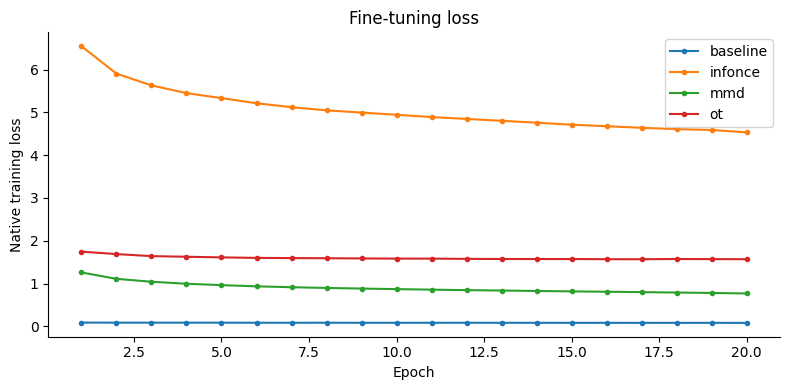

In [18]:
assets = output_dir / 'report_assets'
assets.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 4))
for trial in TRIALS:
    history = pd.read_csv(output_dir / trial / 'history.csv')
    ax.plot(history['epoch'], history['metric_loss'], marker='o', ms=3, label=trial)
ax.set(xlabel='Epoch', ylabel='Native training loss', title='Fine-tuning loss')
ax.legend()
sns.despine()
fig.tight_layout()
fig.savefig(assets / 'loss_histories.png', dpi=180)
plt.show()

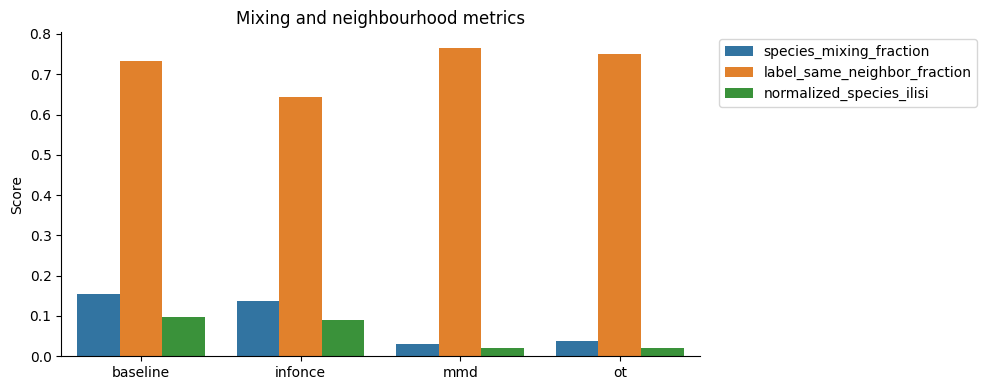

In [19]:
plot_frame = summary.melt(
    id_vars='trial',
    value_vars=['species_mixing_fraction', 'label_same_neighbor_fraction', 'normalized_species_ilisi'],
    var_name='metric', value_name='value',
)
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_frame, x='trial', y='value', hue='metric', ax=ax)
ax.set(title='Mixing and neighbourhood metrics', xlabel=None, ylabel='Score')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
fig.tight_layout()
fig.savefig(assets / 'mixing_metrics.png', dpi=180)
plt.show()

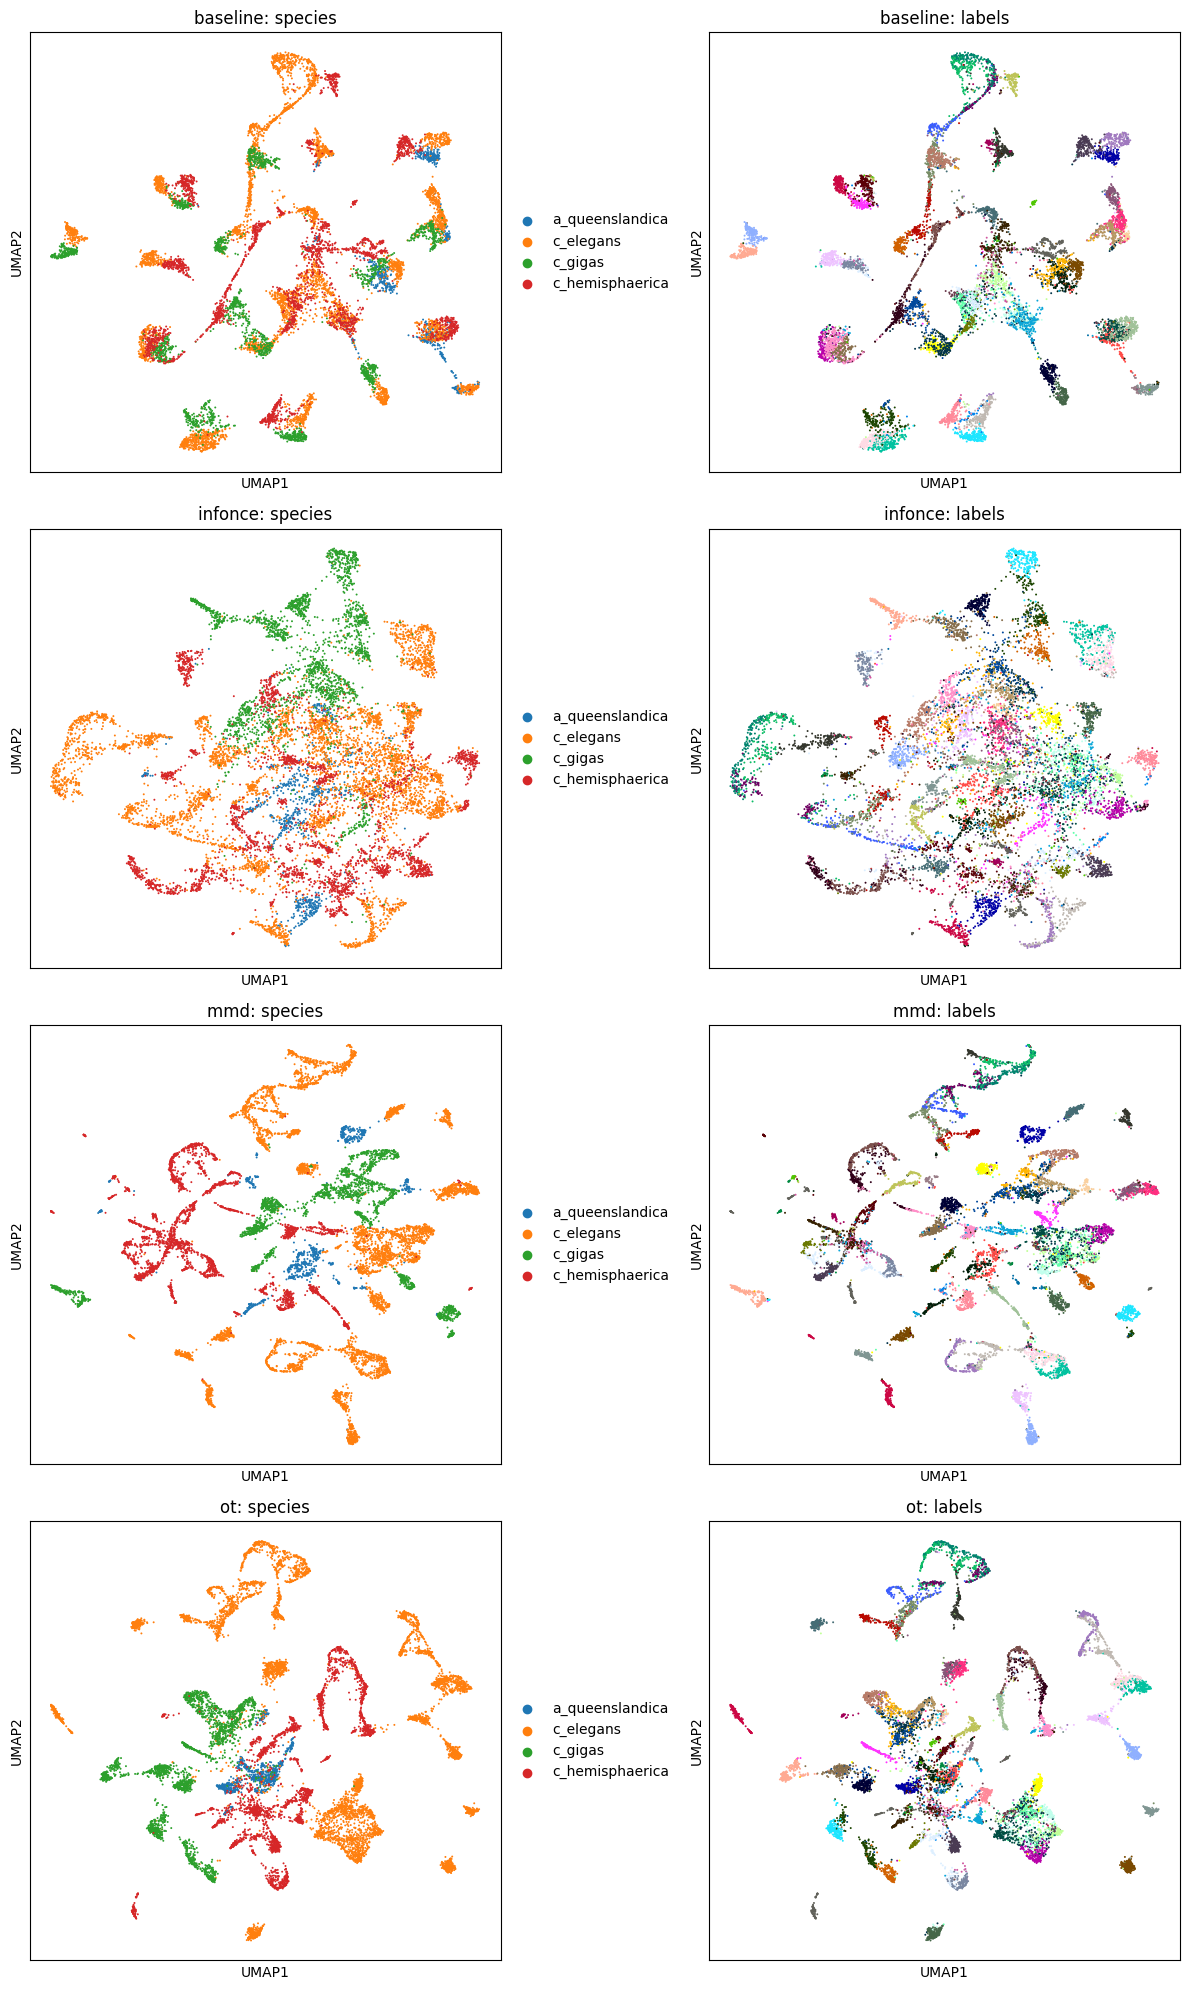

In [20]:
fig, axes = plt.subplots(len(TRIALS), 2, figsize=(12, 20))
for row, trial in enumerate(TRIALS):
    trial_adata = sc.read_h5ad(output_dir / trial / 'evaluated_adata.h5ad')
    sc.pl.umap(trial_adata, color='species', ax=axes[row, 0], show=False, title=f'{trial}: species', size=8)
    sc.pl.umap(trial_adata, color='labels2', ax=axes[row, 1], show=False, title=f'{trial}: labels', size=8, legend_loc=None)
fig.tight_layout()
fig.savefig(assets / 'trial_umaps.png', dpi=180, bbox_inches='tight')
plt.show()

## Discussion prompts

- InfoNCE achieved baseline-comparable mixing and a lower frozen-triplet loss, but lost label-neighbour purity.
- MMD and OT preserved more local structure but did not create enough cross-species mixing under this protocol.
- The strict artifact audit demonstrates that these outcomes were obtained without labels entering fine-tuning or checkpoint selection.
- The benchmark therefore exposes the central tradeoff directly: species invariance versus preservation of cell-state neighbourhoods.